# 🛠️ Preparação dos Dados

In [5]:
import pandas as pd
df = pd.read_csv("dados_tratados.csv")
df.head()


,id,Churn,genero,idoso,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.6,593.30,2.186667
1,0003-MKNFE,não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.9,542.40,1.996667
2,0004-TLHLJ,sim,Masculino,0,Não,Não,4,Sim,Não,Fibra óptica,...,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.9,280.85,2.463333
3,0011-IGKFF,sim,Masculino,1,Sim,Não,13,Sim,Não,Fibra óptica,...,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.0,1237.85,3.266667
4,0013-EXCHZ,sim,Feminino,1,Sim,Não,3,Sim,Não,Fibra óptica,...,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.9,267.40,2.796667


In [13]:
# Remoção de colunas irrelevantes
df = df.drop(columns=["id"])
df.head()

,Churn,genero,idoso,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,Não,...,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.6,593.30,2.186667
1,não,Masculino,0,Não,Não,9,Sim,Sim,DSL,Não,...,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.9,542.40,1.996667
2,sim,Masculino,0,Não,Não,4,Sim,Não,Fibra óptica,Não,...,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.9,280.85,2.463333
3,sim,Masculino,1,Sim,Não,13,Sim,Não,Fibra óptica,Não,...,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.0,1237.85,3.266667
4,sim,Feminino,1,Sim,Não,3,Sim,Não,Fibra óptica,Não,...,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.9,267.40,2.796667


In [14]:
#Encoding
df_model = pd.get_dummies(df, drop_first=True)

In [16]:
#Proporção de Evasão
df_model["Churn_sim"].value_counts(normalize=True)

,proportion
Churn_sim,
False,0.734215
True,0.265785


In [18]:
# Balanceamento de Classes
from imblearn.over_sampling import SMOTE

# Drop rows with any NaN values from df_model before splitting into X and y
df_model_clean = df_model.dropna()

X = df_model_clean.drop(columns=["Churn_sim"])
y = df_model_clean["Churn_sim"]

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

In [19]:
# Normalização
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_res_scaled = scaler.fit_transform(X_res)

# 🎯 Correlação e Seleção de Variáveis

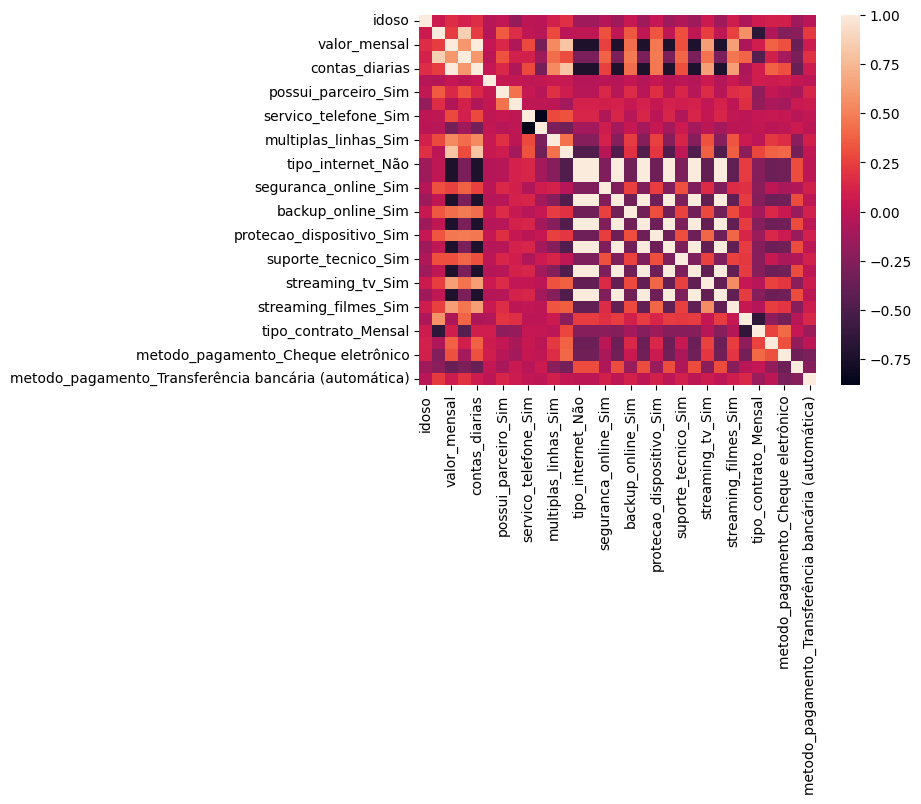

In [20]:
# Análise de Correlação
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(pd.DataFrame(X_res).corr())
plt.show()

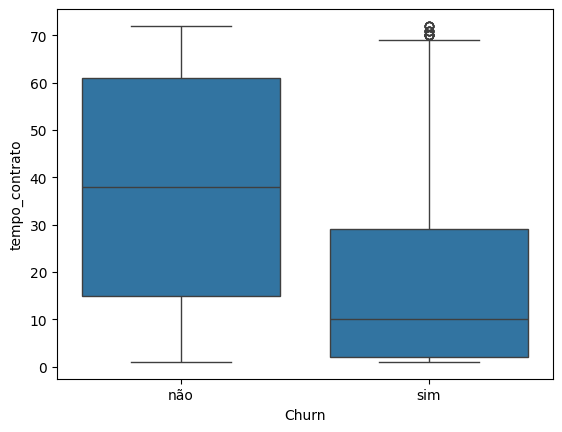

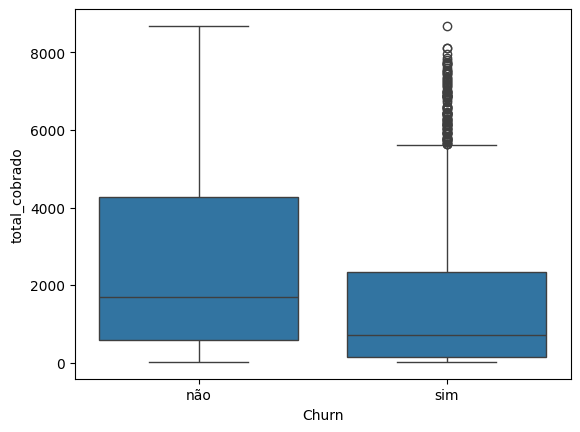

In [22]:
# Análises Direcionadas
sns.boxplot(x=df["Churn"], y=df["tempo_contrato"])
plt.show()

sns.boxplot(x=df["Churn"], y=df["total_cobrado"])
plt.show()

# 🤖 Modelagem Preditiva

In [26]:
# Separação Treino/Teste
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_res_scaled, y_res, test_size=0.3, random_state=42, stratify=y_res
)

In [27]:
# Criação de Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_res, y_res)

RandomForestClassifier(n_estimators=200, random_state=42)

In [28]:
# Avaliação dos Modelos
# Modelo 1 -  Regressão Logística
from sklearn.metrics import classification_report, confusion_matrix

print("Regressão Logística")
print(classification_report(y_test, lr.predict(X_test)))
print(confusion_matrix(y_test, lr.predict(X_test)))


Regressão Logística
              precision    recall  f1-score   support

       False       0.85      0.80      0.82      1549
        True       0.81      0.85      0.83      1549

    accuracy                           0.83      3098
   macro avg       0.83      0.83      0.83      3098
weighted avg       0.83      0.83      0.83      3098

[[1243  306]
 [ 225 1324]]


In [29]:
# Modelo 2 - Random Forest
print("Random Forest")
print(classification_report(y_res, rf.predict(X_res)))
print(confusion_matrix(y_res, rf.predict(X_res)))


Random Forest
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      5163
        True       1.00      1.00      1.00      5163

    accuracy                           1.00     10326
   macro avg       1.00      1.00      1.00     10326
weighted avg       1.00      1.00      1.00     10326

[[5151   12]
 [   6 5157]]


# 📋  Interpretação e Conclusões

In [32]:
# Análise de Importância das Variáveis
import pandas as pd

pd.Series(lr.coef_[0], index=X.columns).sort_values(key=abs, ascending=False).head(10)


,0
contas_diarias,-6.811569
valor_mensal,-6.811569
tipo_internet_Fibra óptica,4.208579
servico_telefone_Sim,4.097435
tempo_contrato,-4.096938
total_cobrado,2.338398
multiplas_linhas_Sem serviço de telefone,1.859535
streaming_tv_Sim,1.619721
metodo_pagamento_Cheque eletrônico,1.498375
streaming_filmes_Sim,1.480656


In [33]:
pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

,0
total_cobrado,0.134034
tempo_contrato,0.125714
tipo_contrato_Mensal,0.124387
contas_diarias,0.100499
valor_mensal,0.100143
metodo_pagamento_Cheque eletrônico,0.071175
tipo_internet_Fibra óptica,0.041830
fatura_digital_Sim,0.039040
tipo_contrato_Bienal,0.024733
genero_Masculino,0.020050


/tmp/ipykernel_391/2388879588.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variável', data=importancia_rf.head(15), palette='viridis')


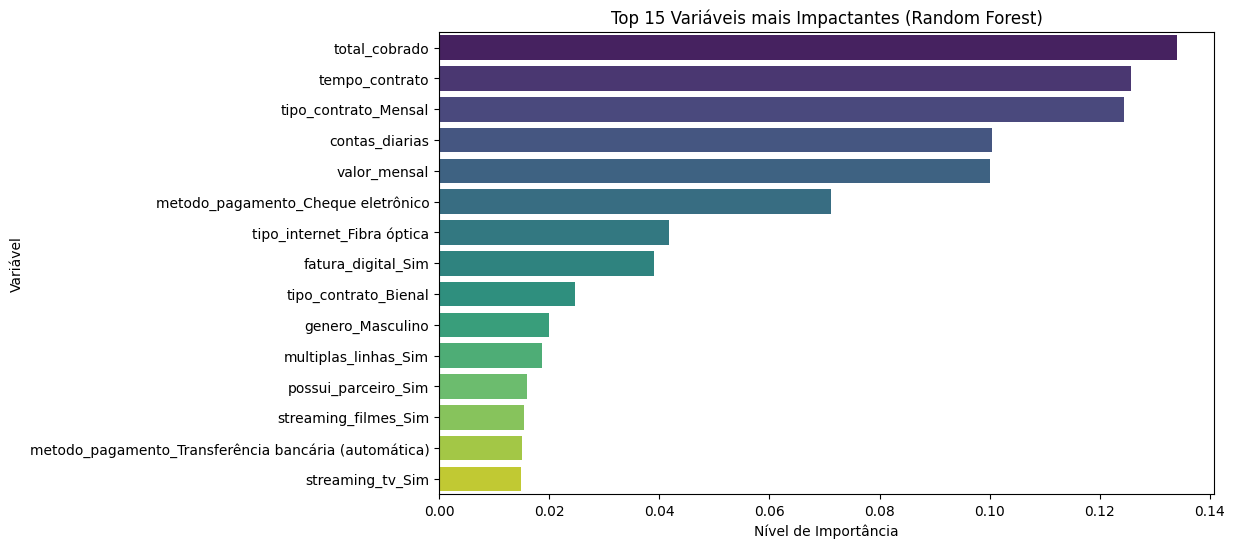

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Definir importancia_rf como um DataFrame para uso no gráfico
importancia_rf = pd.DataFrame({
    'Variável': X.columns,
    'Importancia': rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variável', data=importancia_rf.head(15), palette='viridis')
plt.title('Top 15 Variáveis mais Impactantes (Random Forest)')
plt.xlabel('Nível de Importância')
plt.ylabel('Variável')
plt.show()

In [37]:
# Escolhendo o melhor modelo
print(f'Acurácia Regressão Logística: {lr.score(X_test, y_test)}')
print(f'Acurácia Random Forest: {rf.score(X_test, y_test)}')


Acurácia Regressão Logística: 0.8285990961910911
Acurácia Random Forest: 0.7779212395093609


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Conclusão


A análise demonstrou que fatores como tipo de contrato, tempo de permanência, valor da mensalidade e serviços adicionais exercem grande influência na evasão de clientes.

Os modelos de machine learning se mostraram ferramentas eficazes para prever o churn e identificar clientes em risco. Com base nesses resultados, empresas podem implementar estratégias direcionadas de retenção, reduzindo perdas financeiras e melhorando o relacionamento com os clientes.